In [1]:
# calculate the optimal growth of PNA

import numpy as np 
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from netCDF4 import Dataset as NetCDFFile
import pandas as pd
date         = pd.date_range('1979-01-01','2021-12-31', freq='1D')



nc           = NetCDFFile('/Volumes/Expansion/DATA/Reanalysis/ERA5/z/z250_10anomaly.nc') # load low-pass filtered data
lat          = nc.variables['lat'][:]
lon          = nc.variables['lon'][:]
xx,yy        = np.meshgrid(lon,lat)
lat_lim      = np.array([20, 80])  # [10, 70]
lon_lim      = np.array([100, 300])  # [90, 260]
posi_lat     = np.squeeze(np.where((lat>=lat_lim[0])  & (lat<=lat_lim[1])))                  # 10N - 70N
posi_lon     = np.squeeze(np.where((lon>=lon_lim[0]) & (lon<=lon_lim[1])))                 # 90E - 120W


z            = np.zeros((len(date),3,len(posi_lat),len(posi_lon)))
z[:,0,:,:]   = nc.variables['z'][:,posi_lat[0]:posi_lat[-1]+1,posi_lon[0]:posi_lon[-1]+1]

nc           = NetCDFFile('/Volumes/Expansion/DATA/Reanalysis/ERA5/z/z500_10anomaly.nc') # load low-pass filtered data
z[:,1,:,:]   = nc.variables['z'][:,posi_lat[0]:posi_lat[-1]+1,posi_lon[0]:posi_lon[-1]+1]

nc           = NetCDFFile('/Volumes/Expansion/DATA/Reanalysis/ERA5/z/z850_10anomaly.nc') # load low-pass filtered data
z[:,2,:,:]   = nc.variables['z'][:,posi_lat[0]:posi_lat[-1]+1,posi_lon[0]:posi_lon[-1]+1]


# load PNA index
#del PNA_index

file      = '/Volumes/Expansion/User_backup/Kai-Chih_Tseng/Chaos_and_Predictability/norm.daily.pna.index.b500101.current.ascii'
f         = open(file, 'r')
Lines     = f.readlines()
count     = 0
PNA_index = np.zeros((1,1))
for line in Lines:
    PNA_index = np.append(PNA_index, line.split()[-1])
    count += 1
date      = pd.date_range('1950-01-01','2021-12-31', freq='1D')
posi      = np.squeeze(np.where((date.year>=1979)&(date.year<=2021)))
PNA_index = PNA_index[posi[0]:posi[-1]+1]
posi      = np.squeeze(np.where(PNA_index=='26*******'))
PNA_index = np.array(PNA_index)
for i in range(len(posi)):
    PNA_index[posi[i]] = (PNA_index[posi[i]-1].astype(float)+PNA_index[posi[i]+1].astype(float))/2
PNA_index = np.reshape(PNA_index,[len(PNA_index),1]).astype(float)


In [2]:
# using regression to find PNA pattern
ntime       = z.shape[0]
nlev        = z.shape[1]
nlat        = z.shape[2]
nlon        = z.shape[3]

z_tmp       = np.reshape(z,[ntime,nlev,nlat*nlon])
PNA_pattern = np.zeros((nlev,nlat,nlon))
for level in range(nlev):
    tmp                    = np.linalg.inv(PNA_index.T.dot(PNA_index)).dot(PNA_index.T.dot(z_tmp[:,level,:]))
    PNA_pattern[level,:,:] = np.reshape(tmp,[nlat,nlon])

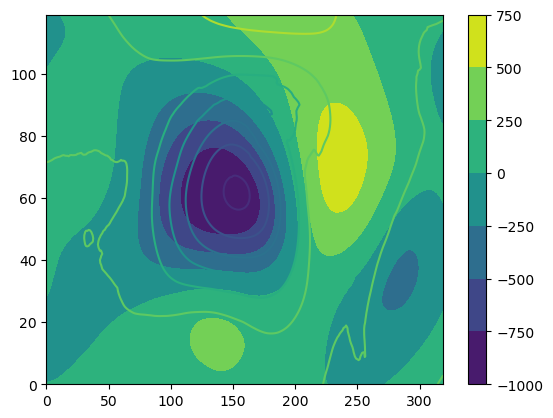

In [3]:
plt.figure()
cs=plt.contourf(PNA_pattern[0,:,:])
plt.contour(PNA_pattern[2,:,:])
plt.colorbar(cs)

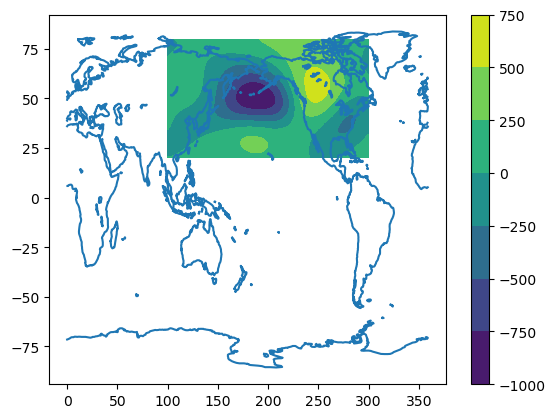

In [4]:
f = open("/Volumes/Expansion/DATA/Reanalysis/Tensor_flow_turtorial/lat.bin", "r")
costal_lat = np.fromfile(f, np.float32)

f = open("/Volumes/Expansion/DATA/Reanalysis/Tensor_flow_turtorial/lon.bin", "r")
costal_lon = np.fromfile(f, np.float32)  

lat_lim      = np.array([20, 80])  # [10, 70]
lon_lim      = np.array([100, 300])  # [90, 260]
posi_lat     = np.squeeze(np.where((lat>=lat_lim[0])  & (lat<=lat_lim[1])))                
posi_lon     = np.squeeze(np.where((lon>=lon_lim[0]) & (lon<=lon_lim[1])))               
xv,yv        = np.meshgrid(lon[posi_lon],lat[posi_lat])


plt.figure()
plt.plot(costal_lon,costal_lat)
cs=plt.contourf(xv,yv,PNA_pattern[0,:,:])
plt.colorbar(cs)

In [42]:
modes        = 50
weight       = np.cos(yv/180*np.pi)
pcs          = np.zeros((modes,ntime))
EOF          = np.zeros((modes,nlev,nlat,nlon))



z_weight     = z.copy()
z_weight     = np.power(weight,0.5)*z_weight
z_weight     = np.reshape(z_weight,[ntime,nlev*nlat*nlon])
from sklearn.decomposition import PCA
pca          = PCA(n_components=modes)
pca.fit(z_weight)
    
pcs          = np.dot(pca.components_,z_weight.T) 
diag         = np.zeros((modes, modes))
np.fill_diagonal(diag, pcs.std(axis=1)) 
pcs          = np.dot(np.linalg.inv(diag),pcs) # normalize (/STD(pcs)) --> dimensionless
EOF          = diag.dot(pca.components_) # (*STD(pcs)) --> has unit
EOF          = np.reshape(pca.components_,[modes,nlev,nlat,nlon])

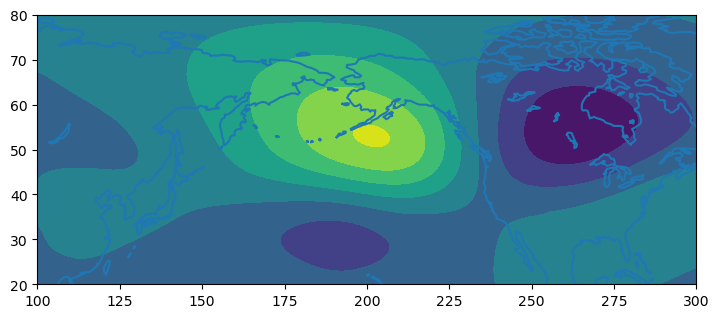

In [43]:
lat_lim      = np.array([20, 80])  # [10, 70]
lon_lim      = np.array([100, 300])  # [90, 260]
posi_lat     = np.squeeze(np.where((lat>=lat_lim[0])  & (lat<=lat_lim[1])))                
posi_lon     = np.squeeze(np.where((lon>=lon_lim[0]) & (lon<=lon_lim[1])))               
xv,yv        = np.meshgrid(lon[posi_lon],lat[posi_lat])

fig=plt.figure()
plt.contourf(xv,yv,EOF[0,0,:,:])
plt.plot(costal_lon,costal_lat)
plt.xlim([100,300])
plt.ylim([20,80])
fig.set_size_inches(8.5, 3.5)

In [44]:
date        = pd.date_range('1979-01-01','2021-12-31', freq='1D')
posi_winter = np.squeeze((np.where((date.month >=10 )|(date.month <=2 ))))
pcs         = np.reshape(pcs,[modes,ntime])

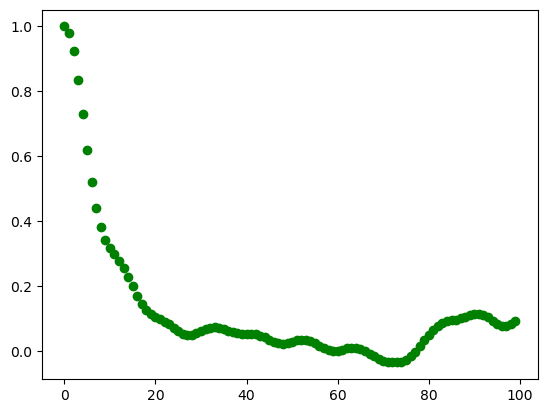

In [45]:
date        = pd.date_range('1979-01-01','2021-12-31', freq='1D')
posi_winter = np.squeeze((np.where((date.month >=10 )|(date.month <=2 ))))
lag         = 100
G           = np.zeros((lag,modes,modes))
for tau in range(0, lag):
    b        = pcs[:,posi_winter-tau]
    c        = pcs[:,posi_winter]
    C_0      = b.dot(b.T)
    C_tau    = c.dot(b.T)
    inv_C_0  = np.linalg.inv(C_0)
    G[tau,:,:] = C_tau.dot(inv_C_0)
    plt.plot(tau, G[tau,1,1], color='green', linestyle='solid', linewidth = 3, 
         marker='o')
plt.show()

In [46]:
r = np.zeros((modes,modes))
for i in np.arange(modes):
    r[i,i] = np.corrcoef(np.squeeze(pcs[i,posi_winter]),np.squeeze(PNA_index[posi_winter]))[0][1]

(array([6]),)

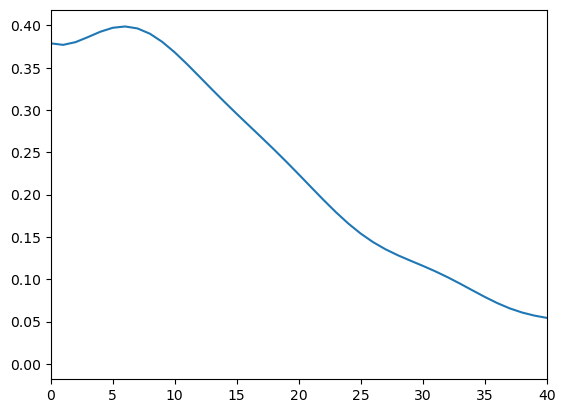

In [54]:
from scipy.linalg import logm, expm
optimal_growth              = np.zeros((lag,))
optimal_growth2             = np.zeros((lag,))
tau                         = 1
G_tmp_original              = G[tau,:,:]
B                           = logm(G_tmp_original)/tau
G_tmp_original1             = expm(B)
lag                         = 100
eig_vect                    = np.zeros((lag,modes,modes))
for i in range(lag):
    GTG                     = np.linalg.matrix_power(G_tmp_original,i).T.dot(r.T.dot(r)).dot(np.linalg.matrix_power(G_tmp_original,i))
    eig_val,eig_vect[i,:,:] = np.linalg.eig(GTG)
    optimal_growth[i,]      = np.max(eig_val)
    
plt.plot(optimal_growth)
#plt.plot(optimal_growth2)
plt.xlim([0,40])
np.where(optimal_growth==np.max(optimal_growth))
#plt.ylim([0,1000])

-0.007449058616067262
-0.00835862570386659
-0.009074881116643849
-0.009623554041291558
-0.009993682396267356
-0.010204754386189095
-0.010314614546019915
-0.010246910171507036
-0.009947944349013662
-0.009426430130717561


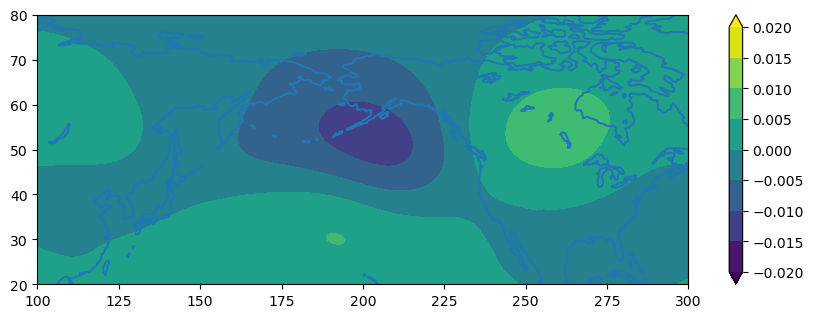

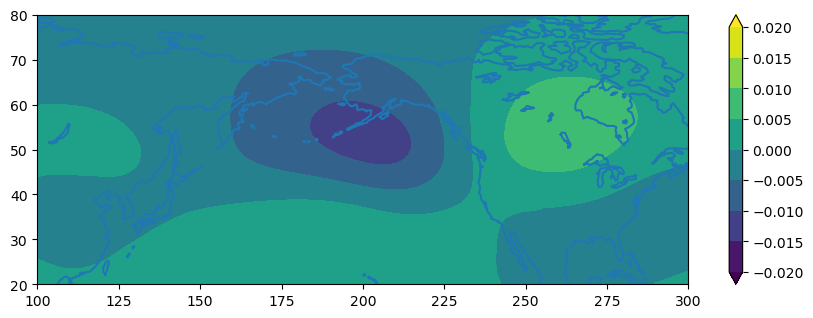

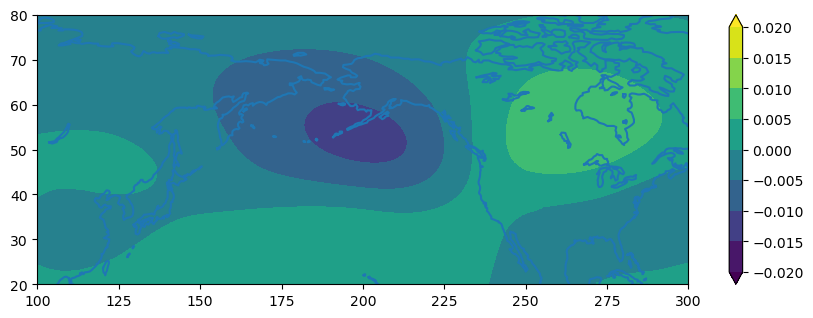

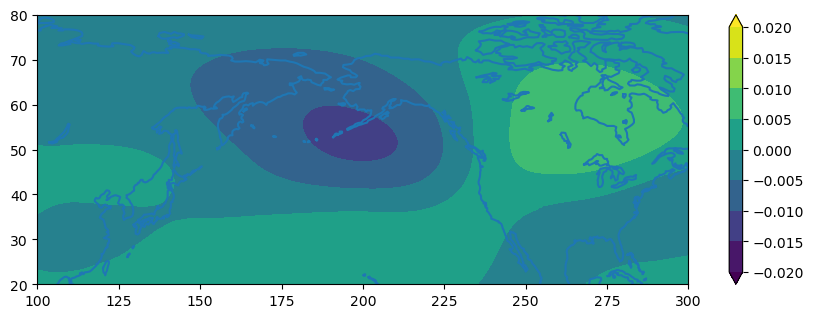

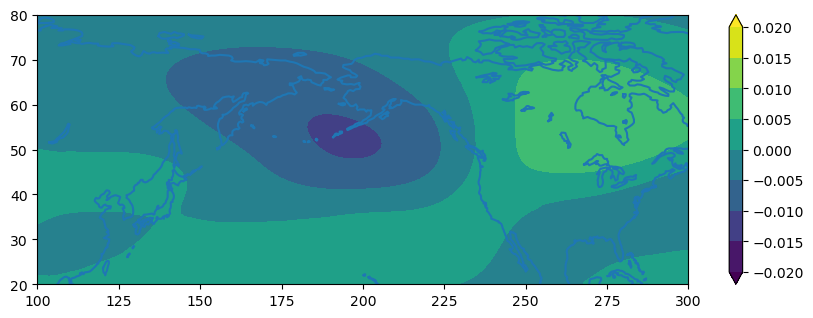

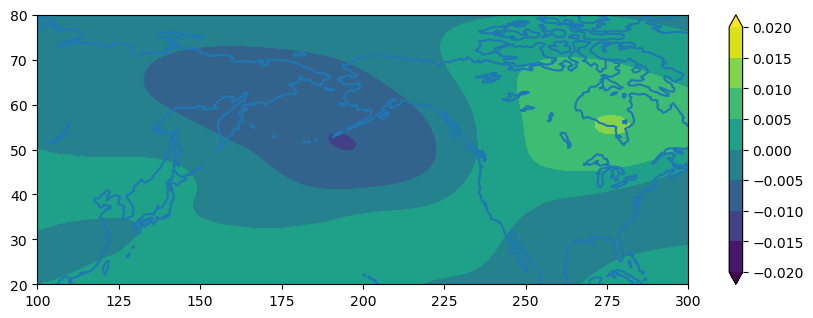

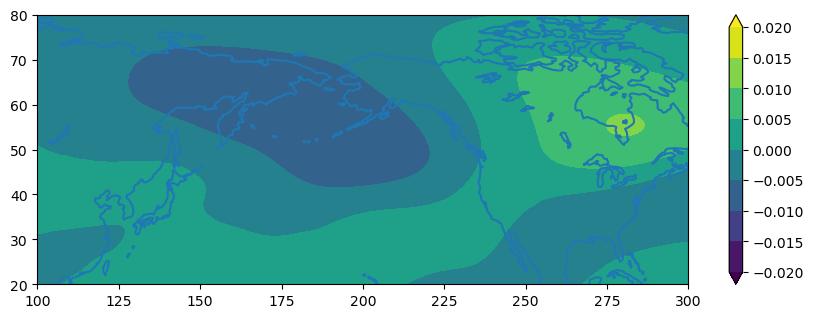

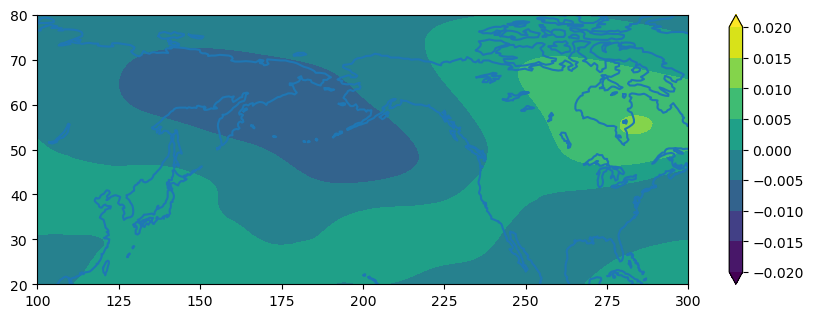

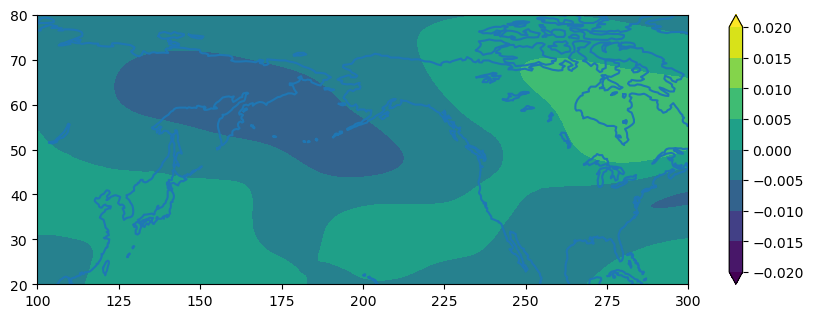

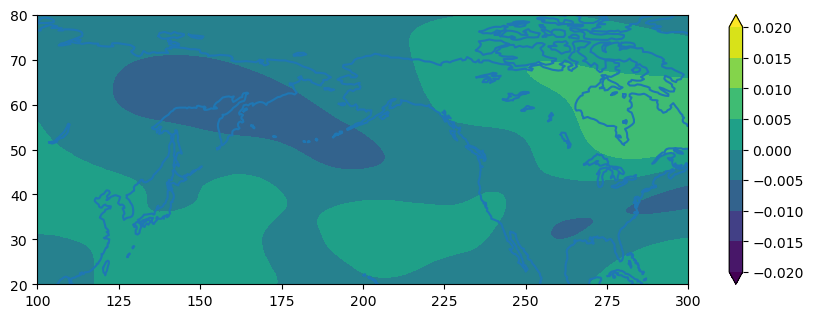

In [49]:
lat_lim      = np.array([20, 80])  # [10, 70]
lon_lim      = np.array([100, 300])  # [90, 260]
posi_lat     = np.squeeze(np.where((lat>=lat_lim[0])  & (lat<=lat_lim[1])))                
posi_lon     = np.squeeze(np.where((lon>=lon_lim[0]) & (lon<=lon_lim[1])))               
xv,yv        = np.meshgrid(lon[posi_lon],lat[posi_lat])

predict_0 = np.reshape(eig_vect[0,:,0],[1,modes]).dot(np.reshape(EOF,[modes,3*120*320]))
predict_0 = np.reshape(predict_0,[3,120,320])

for i in range(0,10):
    predict   = np.reshape(np.linalg.matrix_power(G_tmp_original,i).dot(eig_vect[1,:,0]),[1,modes]).dot(np.reshape(EOF,[modes,3*120*320]))
    predict   = np.reshape(predict,[3,120,320])
    fig = plt.figure()
    cs=plt.contourf(xv,yv,-predict[0,:,:],levels = np.arange(-0.02,0.025,0.005),extend='both')
    print(np.min(predict))
    plt.plot(costal_lon,costal_lat)
    plt.colorbar(cs)
    plt.xlim([100,300])
    plt.ylim([20,80])
    fig.set_size_inches(10.5, 3.5)